# L5 Exercise Answers

*License: CC-BY-NC-SA 4.0*

*Author: Murilo M. Marinho (murilo.marinho@manchester.ac.uk)*

## I found an issue
Thank you! Please report it at https://github.com/MarinhoLab/OpenExecutableBooksRobotics/issues

#### Latex Macros
$\providecommand{\myvec}[1]{{\mathbf{\boldsymbol{{#1}}}}}$
$\providecommand{\mymatrix}[1]{{\mathbf{\boldsymbol{{#1}}}}}$

# Package installation

In [1]:
%%capture
%pip install numpy matplotlib
%pip install numpy matplotlib --break-system-packages

# Imports

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from math import pi, sin, cos

# Definition(s)

The function(s) defined below are valid for all solutions.

In [3]:
def damped_pseudo_inverse(A: np.array, damping: float = 0.01):
    """Calculates the damped pseudo inverse of A"""
    if damping == 0:
        raise Exception(f"Damping is {damping} but should be different from zero")
    
    return A.T @ np.linalg.inv(A @ A.T + (damping ** 2) * np.eye(A.shape[0]))

## `PP` Robot

Suppose that we have a `PP` robot defined by the following transformations:
- a translation of $q_0$ along the $x-$axis of the base frame.
- a rotation of 90 degrees with respect to the current frame.
- a translation of $q_1$ along the $x-$axis of the current frame.

For FKM and Jacobian calculation, see lesson 4.

For the control parameters, see lesson 5.

xd = [0.1        0.1        0.31415927]


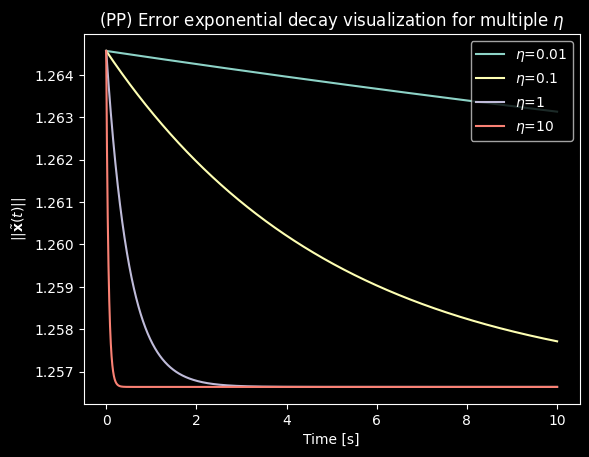

In [4]:
def get_error(x, xd):
    return x - xd

def planar_robot_pp_fkm(q: np.array) -> np.array:
    q_0 = q[0]
    q_1 = q[1]
    return np.array([q_0,
                     q_1,
                     pi/2.0])

def planar_robot_pp_jacobian(q):
    # We can leave the parameter `q` for compatibility, but it's not used for this robot.
    return np.array(
        [[1, 0],
         [0, 1],
         [0, 0]]
    )

etas = [0.01, 0.1, 1, 10] # Different gains to iterate over the same control goals
T = 0.001 # Sampling time
# A desired task-space value, defined by the problem at hand
xd = np.array([2.0,
               2.0,
               pi/10])
print(f"xd = {xd}")

# Lists to store the value of each control iteration
x_tilde_norm_list = []
t_list = []
u_norm_list = []

# Run the controller again for each gain
for i in range(0, len(etas)):
    # Define a stop criteria, in this case let's control for 10 seconds
    t = 0 # Current time
    eta = etas[i]
    # Define initial values for the joint positions
    q_0 = 0.0
    q_1 = 0.0
    q = np.array([q_0,
                  q_1])

    x_tilde_norm_list.append([])
    t_list.append([])
    u_norm_list.append([])

    while t < 10:
        # Calculate task-space value, x
        x = planar_robot_pp_fkm(q)
        # Calculate task-space error, x_tilde
        x_tilde = get_error(x, xd)
        # Get the Jacobian
        J = planar_robot_pp_jacobian(q)
        # Invert the Jacobian using the damped pseudo-inverse
        J_inv = damped_pseudo_inverse(J)
        # Calculate the control action
        u = -eta * J_inv @ x_tilde

        ## Store values in the list so that we can print them later
        x_tilde_norm_list[i].append(np.linalg.norm(x_tilde))
        t_list[i].append(t)
        u_norm_list[i].append(np.linalg.norm(u))

        ## Variable updated for the next loop
        q = q + u * T # Update law using the sampling time
        t = t + T


    plt.plot(t_list[i],x_tilde_norm_list[i], label=f"$\\eta$={eta}")

plt.title('(PP) Error exponential decay visualization for multiple $\\eta$')
plt.legend(loc="upper right")
plt.xlabel("Time [s]")
plt.ylabel("$||\\tilde{ \\bf{x} } (t) ||$")
plt.show()

## `RP` Robot

Suppose that we have a `RP` robot defined by the following transformations:
- a rotation of $q_0$ of the base frame.
- a translation of $q_1$ along the $x-$axis of the current frame.

For FKM and Jacobian calculation, see lesson 4.

For the control parameters, see lesson 5.